# Import Libraries

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Set visualization style
sns.set(style='whitegrid')


## Load the Dataset

In [5]:
# Load the dataset
df = pd.read_csv("C:/Users/manideep/Downloads/AiML_Project/Dataset/data_file.csv")

In [6]:
# Display first 5 rows
df.head()

,FileName,md5Hash,Machine,DebugSize,DebugRVA,MajorImageVersion,MajorOSVersion,ExportRVA,ExportSize,IatVRA,MajorLinkerVersion,MinorLinkerVersion,NumberOfSections,SizeOfStackReserve,DllCharacteristics,ResourceSize,BitcoinAddresses,Benign
0,0124e21d-018c-4ce0-92a3-b9e205a76bc0.dll,79755c51e413ed3c6be4635fd729a6e1,332,0,0,0,4,0,0,8192,8,0,3,1048576,34112,672,0,1
1,05c8318f98a5d301d80000009c316005.vertdll.dll,95e19f3657d34a432eada93221b0ea16,34404,84,121728,10,10,126576,4930,0,14,10,8,262144,16864,1024,0,1
2,06054fba-5619-4a86-a861-ffb0464bef5d.dll,85c32641d77a54e19ba8ea4ab305c791,332,0,0,0,4,0,0,8192,8,0,3,1048576,34112,672,0,1
3,075822ac99a5d301660400009c316005.adhapi.dll,62e3b959d982ef534b66f819fe15f085,34404,84,19904,10,10,21312,252,18160,14,10,6,262144,16736,1040,0,1
4,090607dd9ba5d301ca0900009c316005.SensorsNative...,ae38c5f7d313ad0ff3bfb8826476767f,34404,84,97728,10,10,105792,1852,70592,14,10,7,262144,16736,1096,0,1


In [7]:
# Check dataset dimensions and information
print("Dataset shape:", df.shape)

Dataset shape: (62485, 18)


Data Informatation

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62485 entries, 0 to 62484
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   FileName            62485 non-null  object
 1   md5Hash             62485 non-null  object
 2   Machine             62485 non-null  int64 
 3   DebugSize           62485 non-null  int64 
 4   DebugRVA            62485 non-null  int64 
 5   MajorImageVersion   62485 non-null  int64 
 6   MajorOSVersion      62485 non-null  int64 
 7   ExportRVA           62485 non-null  int64 
 8   ExportSize          62485 non-null  int64 
 9   IatVRA              62485 non-null  int64 
 10  MajorLinkerVersion  62485 non-null  int64 
 11  MinorLinkerVersion  62485 non-null  int64 
 12  NumberOfSections    62485 non-null  int64 
 13  SizeOfStackReserve  62485 non-null  int64 
 14  DllCharacteristics  62485 non-null  int64 
 15  ResourceSize        62485 non-null  int64 
 16  BitcoinAddresses    62

In [10]:
df.describe()

,Machine,DebugSize,DebugRVA,MajorImageVersion,MajorOSVersion,ExportRVA,ExportSize,IatVRA,MajorLinkerVersion,MinorLinkerVersion,NumberOfSections,SizeOfStackReserve,DllCharacteristics,ResourceSize,BitcoinAddresses,Benign
count,62485.000000,6.248500e+04,6.248500e+04,62485.000000,62485.000000,6.248500e+04,6.248500e+04,6.248500e+04,62485.000000,62485.000000,62485.000000,6.248500e+04,62485.000000,6.248500e+04,62485.000000,62485.000000
mean,6756.472657,2.587048e+04,1.541611e+05,58.785997,5.417524,8.953186e+05,4.094623e+05,1.466311e+05,9.782604,6.613171,4.751172,8.759830e+05,12966.031400,1.844664e+05,0.018004,0.433992
std,13345.499919,6.461396e+06,1.903142e+06,1114.068244,2.543697,3.779527e+07,2.851820e+07,1.124630e+06,9.047157,16.976465,2.138584,6.288189e+05,15762.725511,1.732625e+07,0.132968,0.495628
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,1.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000
25%,332.000000,0.000000e+00,0.000000e+00,0.000000,4.000000,0.000000e+00,0.000000e+00,4.096000e+03,6.000000,0.000000,3.000000,2.621440e+05,0.000000,1.080000e+03,0.000000,0.000000
50%,332.000000,0.000000e+00,0.000000e+00,0.000000,5.000000,0.000000e+00,0.000000e+00,8.520000e+03,9.000000,0.000000,5.000000,1.048576e+06,320.000000,2.496000e+03,0.000000,0.000000
75%,332.000000,2.800000e+01,1.283200e+04,6.000000,6.000000,2.875200e+04,1.040000e+02,6.553600e+04,11.000000,10.000000,6.000000,1.048576e+06,32768.000000,2.350400e+04,0.000000,1.000000
max,43620.000000,1.615155e+09,2.852127e+08,63325.000000,260.000000,2.147484e+09,2.415919e+09,6.615450e+07,255.000000,255.000000,33.000000,1.677722e+07,58632.000000,4.294942e+09,1.000000,1.000000


# Exploratory Data Analysis (EDA)

## Univariate Analysis

### Target Variable Analysis

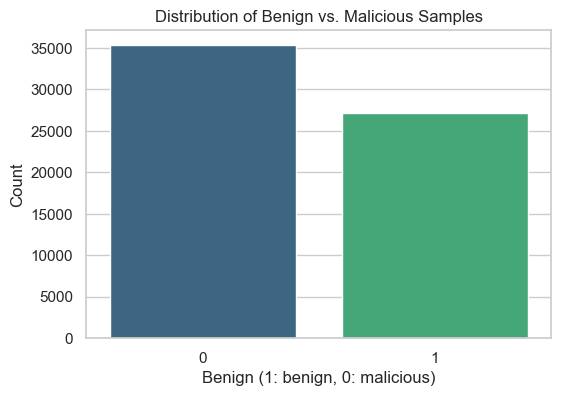

In [14]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Benign', data=df, palette='viridis')
plt.title('Distribution of Benign vs. Malicious Samples')
plt.xlabel('Benign (1: benign, 0: malicious)')
plt.ylabel('Count')
plt.show()

## Bivariate Analysis

### Box Plot Grouped by Label

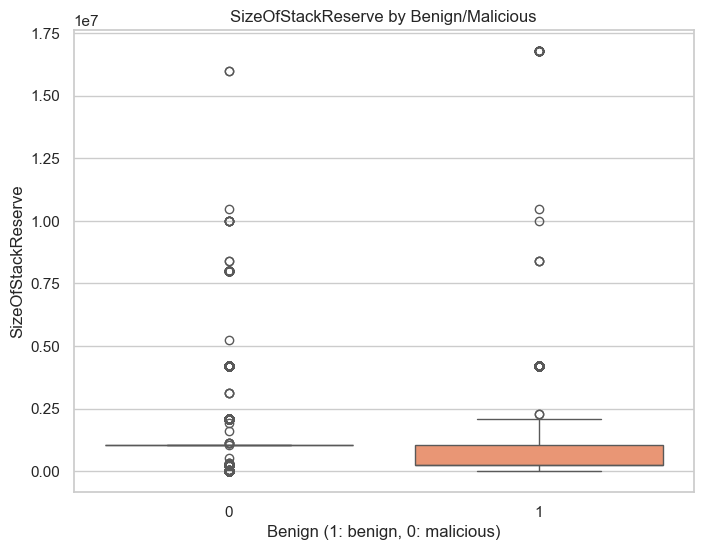

In [17]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Benign', y='SizeOfStackReserve', data=df, palette='Set2')
plt.title('SizeOfStackReserve by Benign/Malicious')
plt.xlabel('Benign (1: benign, 0: malicious)')
plt.ylabel('SizeOfStackReserve')
plt.show()


## Multivariate Analysis

### Pair Plot for Selected Features

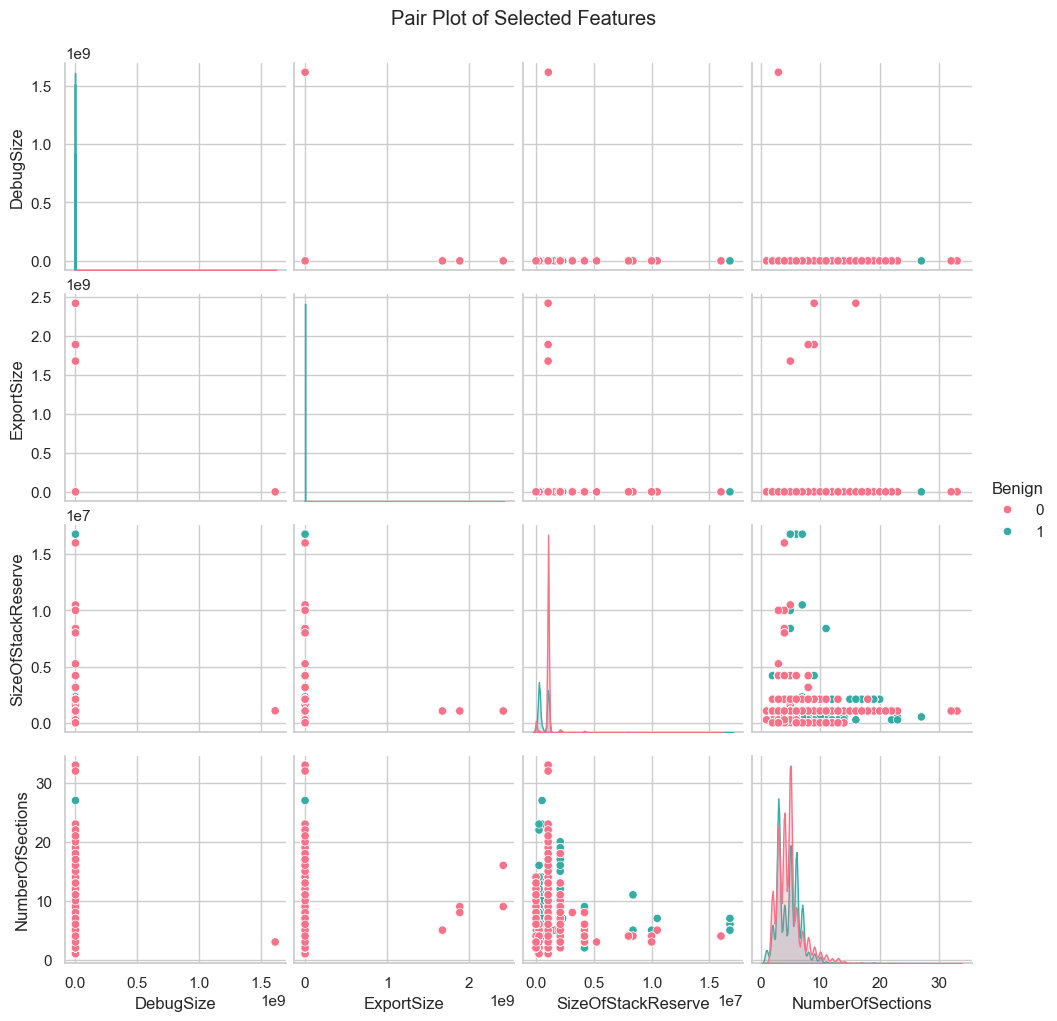

In [20]:
selected_cols = ['DebugSize', 'ExportSize', 'SizeOfStackReserve', 'NumberOfSections', 'Benign']
sns.pairplot(df[selected_cols], hue='Benign', palette='husl', diag_kind='kde')
plt.suptitle('Pair Plot of Selected Features', y=1.02)
plt.show()


### Correlation Heatmap

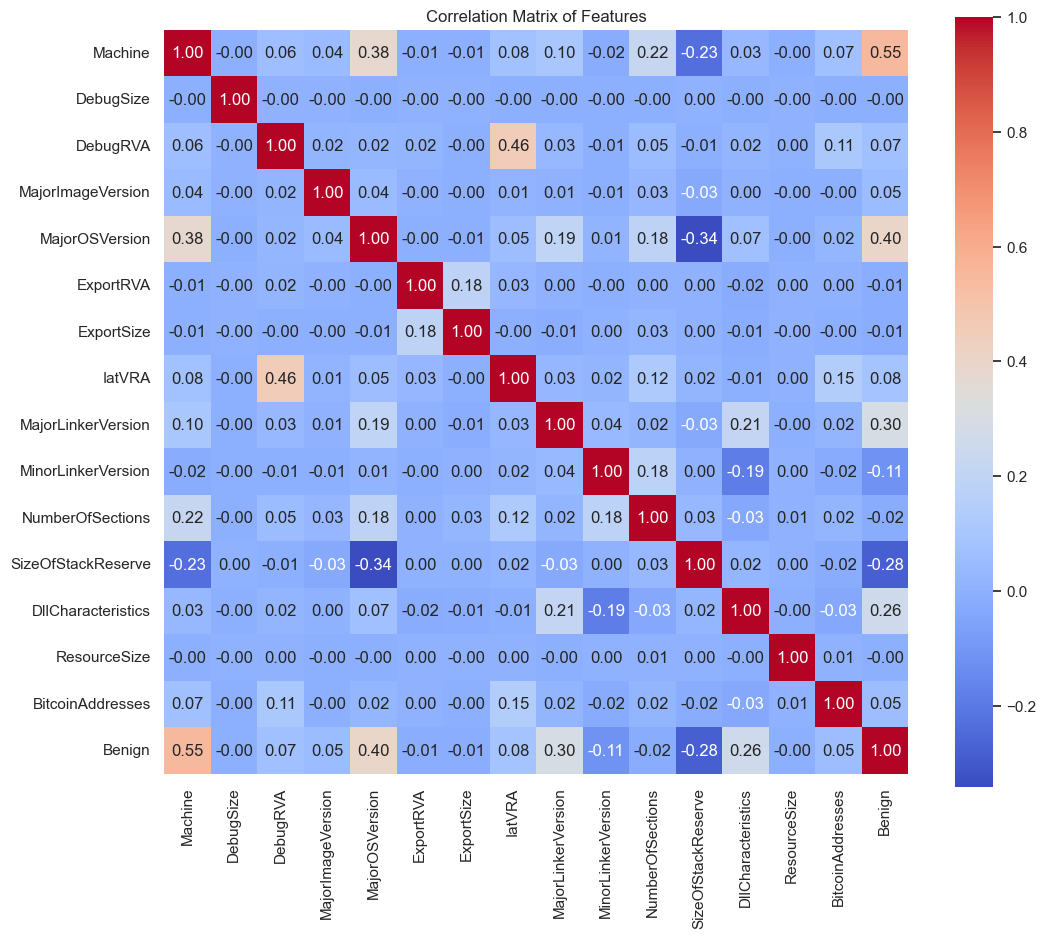

In [22]:
plt.figure(figsize=(12, 10))
# Select only numeric features for correlation calculation
numeric_df = df.select_dtypes(include=np.number)
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix of Features')
plt.show()

# EDA

Distribution of NumberOfSections

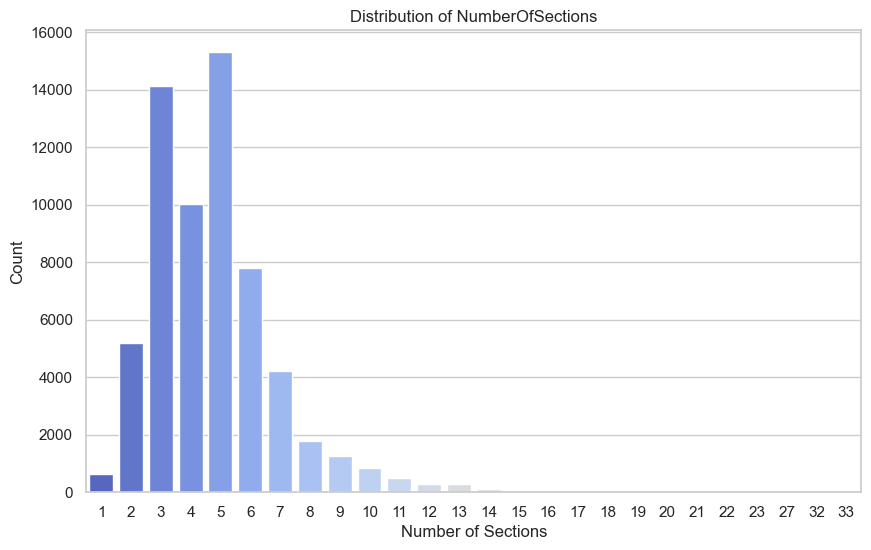

In [25]:
plt.figure(figsize=(10, 6))
sns.countplot(x='NumberOfSections', data=df, palette='coolwarm')
plt.title('Distribution of NumberOfSections')
plt.xlabel('Number of Sections')
plt.ylabel('Count')
plt.show()

Violin Plot of SizeOfStackReserve by Label

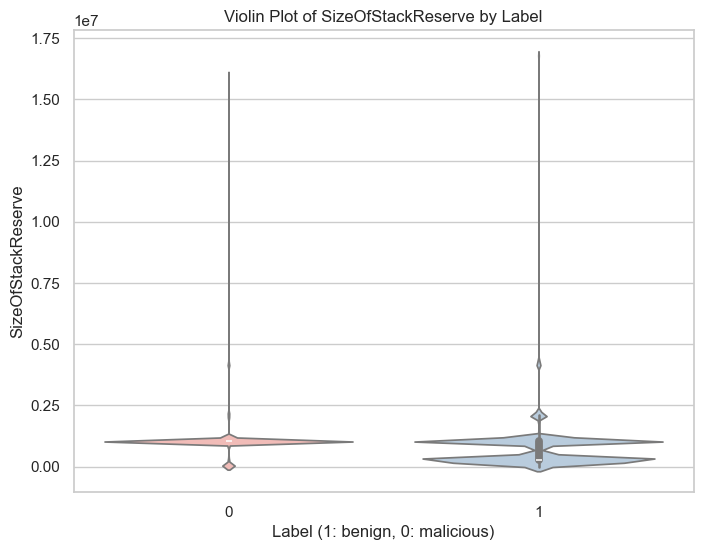

In [27]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='Benign', y='SizeOfStackReserve', data=df, palette='Pastel1')
plt.title('Violin Plot of SizeOfStackReserve by Label')
plt.xlabel('Label (1: benign, 0: malicious)')
plt.ylabel('SizeOfStackReserve')
plt.show()

Proportion of Benign vs. Malicious Files

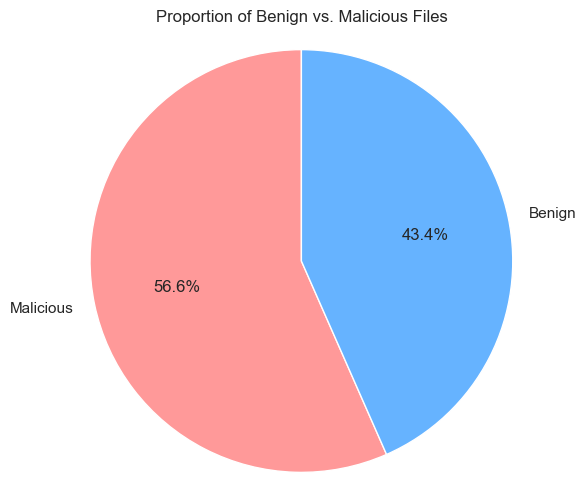

In [29]:
# Calculate counts for each class
label_counts = df['Benign'].value_counts()
labels = ['Malicious' if x == 0 else 'Benign' for x in label_counts.index]

plt.figure(figsize=(6, 6))
plt.pie(label_counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title('Proportion of Benign vs. Malicious Files')
plt.axis('equal')
plt.show()

## Data Cleaning and Pre-processing

### Handling Missing Values

In [32]:
print(df.isnull().sum())

FileName              0
md5Hash               0
Machine               0
DebugSize             0
DebugRVA              0
MajorImageVersion     0
MajorOSVersion        0
ExportRVA             0
ExportSize            0
IatVRA                0
MajorLinkerVersion    0
MinorLinkerVersion    0
NumberOfSections      0
SizeOfStackReserve    0
DllCharacteristics    0
ResourceSize          0
BitcoinAddresses      0
Benign                0
dtype: int64


In [33]:
# Impute missing values with median for numeric columns only
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

### Remove Duplicate Entries

In [35]:
df.drop_duplicates(inplace=True)

## Feature Scaling

In [37]:
numeric_features = ['DebugSize', 'ExportSize', 'IatVRA', 'SizeOfStackReserve', 'ResourceSize']  # add others as needed

scaler = StandardScaler()
df[numeric_features] = scaler.fit_transform(df[numeric_features])

### Encoding Categorical Variables

In [39]:
le = LabelEncoder()
df['FileName_encoded'] = le.fit_transform(df['FileName'])

## Feature Selection

### Remove Highly Correlated Features

Recursive Feature Elimination

In [42]:
model = RandomForestClassifier(random_state=42)
# Adjust number of features to select based on your analysis
rfe = RFE(model, n_features_to_select=10)
rfe.fit(df[numeric_features], df['Benign'])
selected_features = [feature for feature, support in zip(numeric_features, rfe.support_) if support]
print("Selected features:", selected_features)


Selected features: ['DebugSize', 'ExportSize', 'IatVRA', 'SizeOfStackReserve', 'ResourceSize']


## Splitting the Dataset

In [44]:
# Define X (features) and y (target)
X = df[selected_features]
y = df['Benign']

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Model Building and Training

### Random Forest

In [48]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print("Random Forest Metrics:")
print(f"Accuracy: {accuracy_rf:.2f}")
print(f"Precision: {precision_rf:.2f}")
print(f"Recall: {recall_rf:.2f}")
print(f"F1 Score: {f1_rf:.2f}")
print(f"AUC-ROC: {auc_rf:.2f}")


Random Forest Metrics:
Accuracy: 0.99
Precision: 0.99
Recall: 0.98
F1 Score: 0.99
AUC-ROC: 1.00


Confusion Matrix Plot

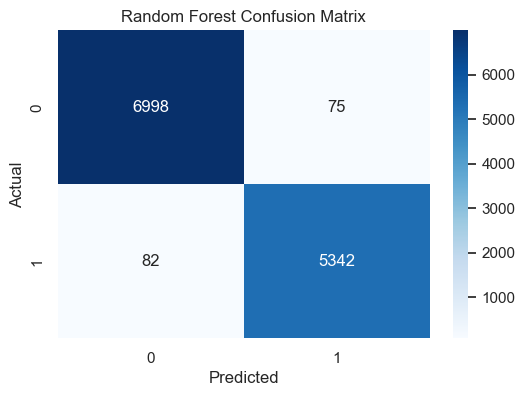

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


ROC Curve

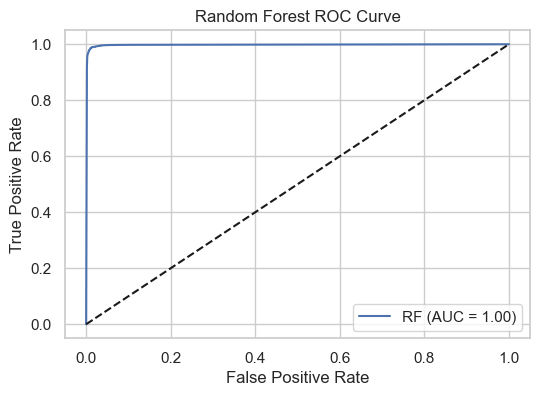

In [53]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
plt.figure(figsize=(6, 4))
plt.plot(fpr_rf, tpr_rf, label=f'RF (AUC = {auc_rf:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend(loc='lower right')
plt.show()

### Support Vector Machine

In [55]:
svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train, y_train)

SVC(probability=True, random_state=42)

Predictions & Metrics

In [57]:
y_pred_svm = svm_model.predict(X_test)
y_pred_proba_svm = svm_model.predict_proba(X_test)[:, 1]

accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
auc_svm = roc_auc_score(y_test, y_pred_proba_svm)

print("SVM Metrics:")
print(f"Accuracy: {accuracy_svm:.2f}")
print(f"Precision: {precision_svm:.2f}")
print(f"Recall: {recall_svm:.2f}")
print(f"F1 Score: {f1_svm:.2f}")
print(f"AUC-ROC: {auc_svm:.2f}")


SVM Metrics:
Accuracy: 0.80
Precision: 0.95
Recall: 0.57
F1 Score: 0.72
AUC-ROC: 0.81


Confusion Matrix

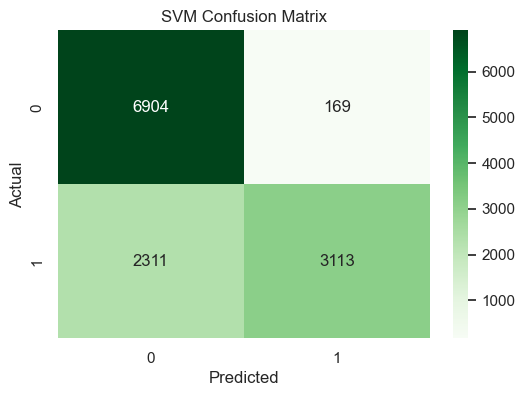

In [59]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens')
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

ROC Curve

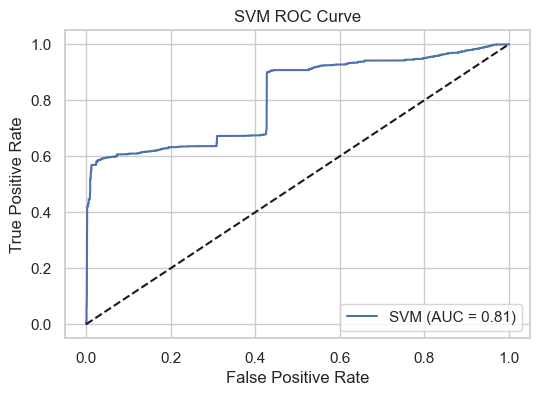

In [61]:
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_pred_proba_svm)
plt.figure(figsize=(6, 4))
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM ROC Curve')
plt.legend(loc='lower right')
plt.show()

### XGBoost

In [63]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

Predictions & Metrics

In [65]:
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

print("XGBoost Metrics:")
print(f"Accuracy: {accuracy_xgb:.2f}")
print(f"Precision: {precision_xgb:.2f}")
print(f"Recall: {recall_xgb:.2f}")
print(f"F1 Score: {f1_xgb:.2f}")
print(f"AUC-ROC: {auc_xgb:.2f}")

XGBoost Metrics:
Accuracy: 0.98
Precision: 0.98
Recall: 0.98
F1 Score: 0.98
AUC-ROC: 1.00


Confusion Matrix

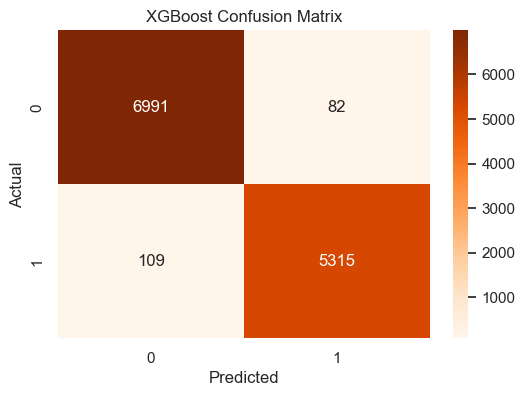

In [67]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges')
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

ROC Curve

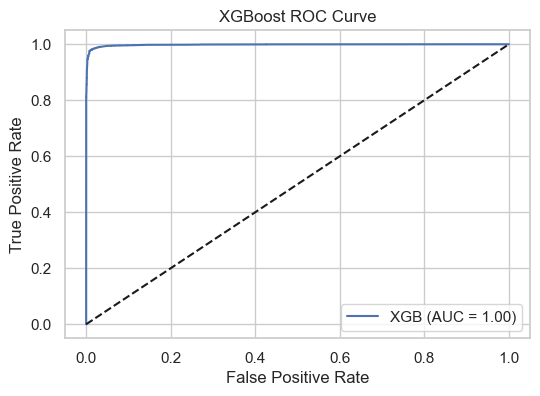

In [69]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
plt.figure(figsize=(6, 4))
plt.plot(fpr_xgb, tpr_xgb, label=f'XGB (AUC = {auc_xgb:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve')
plt.legend(loc='lower right')
plt.show()

## Logistic Regression

In [71]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

Predictions & Metrics

In [73]:
y_pred_lr = lr_model.predict(X_test)
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_pred_proba_lr)

print("Logistic Regression Metrics:")
print(f"Accuracy: {accuracy_lr:.2f}")
print(f"Precision: {precision_lr:.2f}")
print(f"Recall: {recall_lr:.2f}")
print(f"F1 Score: {f1_lr:.2f}")
print(f"AUC-ROC: {auc_lr:.2f}")

Logistic Regression Metrics:
Accuracy: 0.78
Precision: 0.87
Recall: 0.59
F1 Score: 0.70
AUC-ROC: 0.72


 Confusion Matrix

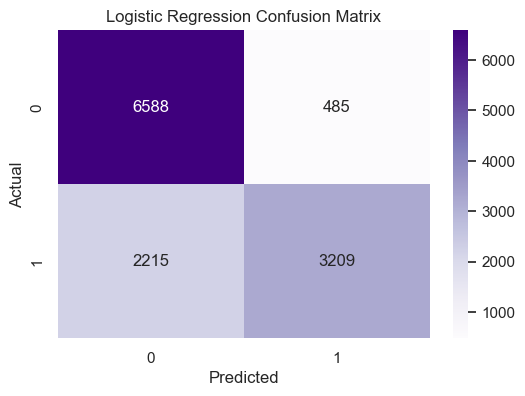

In [75]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Purples')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

 ROC Curve

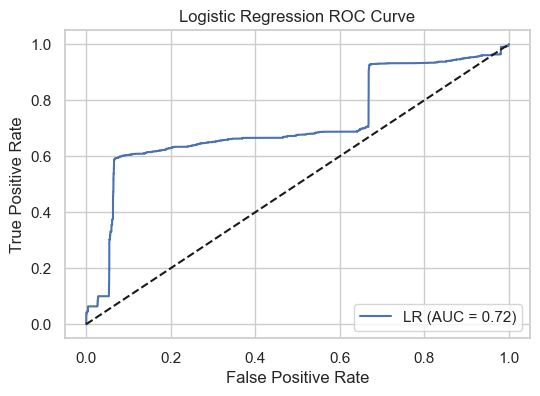

In [77]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
plt.figure(figsize=(6, 4))
plt.plot(fpr_lr, tpr_lr, label=f'LR (AUC = {auc_lr:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve')
plt.legend(loc='lower right')
plt.show()

# Model Comparison

In [79]:
import pandas as pd

comparison_data = {
    'Model': ['Random Forest', 'SVM', 'XGBoost', 'Logistic Regression'],
    'Accuracy': [accuracy_rf, accuracy_svm, accuracy_xgb, accuracy_lr],
    'Precision': [precision_rf, precision_svm, precision_xgb, precision_lr],
    'Recall': [recall_rf, recall_svm, recall_xgb, recall_lr],
    'F1 Score': [f1_rf, f1_svm, f1_xgb, f1_lr],
    'AUC-ROC': [auc_rf, auc_svm, auc_xgb, auc_lr]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,AUC-ROC
0,Random Forest,0.987437,0.986155,0.984882,0.985518,0.997522
1,SVM,0.801552,0.948507,0.573931,0.715139,0.809058
2,XGBoost,0.984716,0.984806,0.979904,0.982349,0.998087
3,Logistic Regression,0.783948,0.868706,0.591630,0.703882,0.716287


In [80]:
# Best Model
best_model_row = comparison_df.loc[comparison_df['Accuracy'].idxmax()]
print("The best model based on accuracy is:", best_model_row['Model'])
best_model_row

The best model based on accuracy is: Random Forest


Model        Random Forest
Accuracy          0.987437
Precision         0.986155
Recall            0.984882
F1 Score          0.985518
AUC-ROC           0.997522
Name: 0, dtype: object

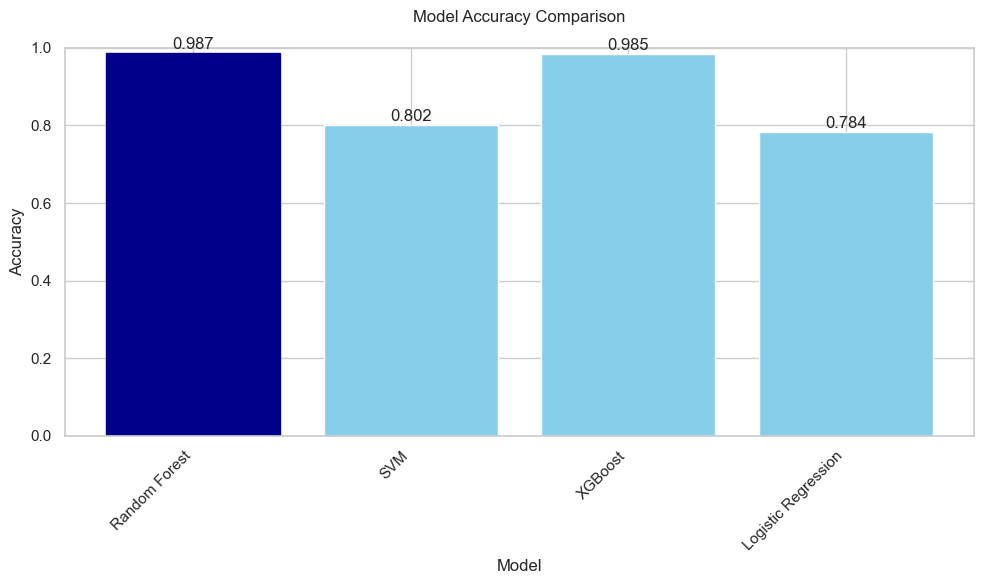

In [81]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
models = comparison_df['Model']
accuracies = comparison_df['Accuracy']
bars = plt.bar(models, accuracies, color='skyblue')
best_model_index = accuracies.idxmax()
bars[best_model_index].set_color('darkblue')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison\n')
plt.ylim(0.0, 1.0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
for bar in bars:
  yval = bar.get_height()
  plt.text(bar.get_x() + bar.get_width()/2, yval + 0.001, round(yval, 3), ha='center', va='bottom')

plt.show()


# Deployment

In [83]:
# Deployment

import pickle
best_model = rf_model
# Save the model to a file
filename = 'malware_detection_model.pkl'
pickle.dump(best_model, open(filename, 'wb'))
print(f"Model saved to {filename}")

Model saved to malware_detection_model.pkl


In [84]:
try:
  with open('malware_detection_model.pkl', 'rb') as f:
    model = pickle.load(f)
    print("Model loaded successfully!")
except FileNotFoundError:
  print("Model file 'malware_detection_model.pkl' not found. Make sure it is deployed correctly.")
except Exception as e:
  print(f"An error occurred while loading the model: {e}")


Model loaded successfully!
